<img src="../../images/arm_logo.png" width=500 alt="ARM Logo"></img>

# ACT Basics
---

:::{important} Goal
The goal of this notebook is to showcase ARM supported open-source software that can be included within your workflows
:::

<a href="https://colab.research.google.com/github/ARM-Development/arm-summer-school-2026/blob/main/notebooks/act/ACT-Basics-BNF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Overview
The [Atmospheric data Community Toolkit (ACT)](https://github.com/ARM-DOE/ACT) is an open source Python toolkit for working with atmospheric time-series datasets of varying dimensions (@theisen_act_2026). The toolkit is meant to have functions for every part of the scientific process: 
- discovery,
- IO, 
- quality control, 
- corrections,
- retrievals,
- visualization, 
- and analysis. 

It is meant to be a community platform for sharing code with the goal of reducing duplication of effort and better connecting the science community with programs such as the Atmospheric Radiation Measurement (ARM) User Facility.

This tutorial will provide an introduction to ACT using the ARM Surface Meteorological Instrumentation [MET](@kyrouac_SGP_MET) at the Southern Great Plains (SGP) to investigate temperature trends over the data record.

1. Intro to ACT
1. Instrument Overview
1. Downloading and Reading in Data
1. Quality Controlling Data
1. Visualizing Data
1. Monthly Temperature Trend Analysis

## Prerequisites
This notebook will rely heavily on Python and the [Atmospheric data Community Toolkit (ACT)](https://github.com/ARM-DOE/ACT).  Don't worry if you don't have experience with either, this notebook will walk you though what you need to know.

:::{admonition} ARM Live Token
You will also need an account and token to download data using the ARM Live webservice.  Navigate to the [webservice information page](https://adc.arm.gov/armlive/) and log in to get your token.  Your account username will be your ARM username.
:::

| Concepts | Importance | Notes |
| --- | --- | --- |
| [ACT](https://arm-doe.github.io/ACT/index.html) | Helpful | |
| [Xarray Basics](https://foundations.projectpythia.org/core/xarray/) | Helpful | Multi-dimensional arrays |
| [Matplotlib Basics](https://foundations.projectpythia.org/core/matplotlib/) | Helpful | Basic plotting |
| [NumPy Basics](https://foundations.projectpythia.org/core/numpy/) | Helpful | Basic arrays |

- **Time to learn**: 15 Minutes
- **System requirements**:
    - Python 3.11 or latest
    - ACT v2.0.0 or latest
    - numpy
    - xarray
    - matplotlib

---

## Intro to ACT
           
The [Atmospheric data Community Toolkit (ACT)](https://github.com/ARM-DOE/ACT) is an open-source Python toolkit for exploring and analyzing atmospheric time-series datasets.  Examples can be found in the [ACT Example Gallery](https://arm-doe.github.io/ACT/source/auto_examples/index.html).  The toolkit has modules for many different parts of the scientific process, including:

<table>
    <tr>
        <td>
            
### Data Discovery (act.discovery)
The [discovery](https://arm-doe.github.io/ACT/API/generated/act.discovery.html) module houses functions to download or access data from different groups.  Currently it includes function to get data for ARM, NOAA, EPA, NEON, and more!

### Input/Output (act.io)
[io](https://arm-doe.github.io/ACT/API/generated/act.io.html) contains functions for reading and writing data from various sources and formats.

### Visualization (act.plotting)
[plotting](https://arm-doe.github.io/ACT/API/generated/act.plotting.html) contains various routines, built on matplotlib, to help visualize and explore data.  These include 
1. Time-series plots
1. Distribution plots like histograms and heatmaps
1. Geographic plots for moving systems like radiosondes or aircraft
1. Skew-T plots for radiosonde data, built off MetPy
1. Wind rose plots for wind and data roses
1. Cross-section plots for working with 3-dimensional data

### Corrections (act.corrections)
[corrections](https://arm-doe.github.io/ACT/API/generated/act.corrections.html) apply different corrections to data based on need.  A majority of the existing corrections are for lidar data.

### Quality Control (act.qc)
The [qc](https://arm-doe.github.io/ACT/API/generated/act.qc.html) module has a lot of functions for working with quality control information, apply new tests, or filtering data based on existing tests.  We will explore some of that functionality in this notebook.

### Retrievals (act.retrievals)
There are many cases in which some additional calculations are necessary to get more value from the instrument data.  The [retrievals](https://arm-doe.github.io/ACT/API/generated/act.retrievals.html) module houses some functions for performing these advanced calculations.  

### Utilities (act.utils)
The [utils](https://arm-doe.github.io/ACT/API/generated/act.utils.html) module has a lot of general utilities to help with the data.  Some of these include adding in a solar variable to indicate day/night (useful in filtering data), unit conversions, decoding WMO weather codes, performing weighted averaging, etc...
        </td>
        <td>
            <center>
            <img src="https://arm-doe.github.io/ACT/_images/sphx_glr_plot_neon_001.png" alt="NEON-ARM"></img>
            <figcaption>ARM and NEON data from Utquivaik, AK</figcaption>
            <img src="https://arm-doe.github.io/ACT/_images/sphx_glr_plot_enhanced_skewt_001.png" alt="SONDE"></img>
            <figcaption>Enhanced Skew-T plot from ARM's Southern Great Plains Site (SGP)</figcaption>
            </center>
        </td>
    </tr>
</table>

---

![ACT-Discovery](../../images/figures/theisen-2026-act-discovery.png)

## Instrument Overview

### Surface Meteorological Instrumentation (MET) -  @Kyrouac_SGP_MET
The ARM Surface Meteorology Systems (MET) use mainly conventional in situ sensors to obtain 1-minute statistics of surface wind speed, wind direction, air temperature, relative humidity, barometric pressure, and rain-rate. [Learn more](https://arm.gov/capabilities/instruments/met)


## Imports
Let's get started with some data!  But first, we need to import some libraries.

:::{admonition}**If Running these Notebooks on Google CoLab**
You will need to include the Atmospheric data Community Toolkit (ACT) within the python environment.
Uncomment the next line prior to importing the python libraries.
:::

In [108]:
# Uncomment if running on CoLab
##!pip install act-atmos>=2.2.23

In [109]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import getpass
import act

![ACT-Bridge](../../images/figures/theisen-2026-act-bridge.png)

## Downloading and Reading ARM's NetCDF Data
ARM's standard file format is NetCDF (network Common Data Form) which makes it very easy to work with in Python!  ARM data are available through a data portal called [Data Discovery](https://adc.arm.gov/discovery/#/) or through a webservice.  If you didn't get your username and token earlier, please go back and see the Prerequisites!

Let's download some of the MET data first from two facilities[^MET-facilities]!

[^MET-facilities]: Location of MET Measurements at SGP's central and extended facilities
    ```{image} ../../images/figures/sgp-met-EF.png
    :alt: MET facilities
    :width: 4000px
    :align: center
    ```

In [ ]:
# Note - recommended ARM Live token to be set as an environmental variable

# Check for env variables, otherwise set your username and token here!
if "ARM_USERNAME" in os.environ:
    arm_username = os.getenv("ARM_USERNAME")
else:
    arm_username = input("Enter ARM username: ").strip()
if "ARM_TOKEN" in os.environ:
    arm_token = os.getenv("ARM_TOKEN")
else:
    arm_token = getpass.getpass("Enter ARM token (hidden): ").strip()

# Set the datastream and start/enddates
cf_datastream = 'sgpmetE13.b1'
ef_datastream = "sgpmetE39.b1"

startdate = '2026-04-01'
enddate = '2026-04-30'

# Use ACT to easily download the data.  Watch for the data citation!  Show some support
# for ARM's instrument experts and cite their data if you use it in a publication
result_cf_met = act.discovery.download_arm_data(arm_username, arm_token, cf_datastream, startdate, enddate)
result_ef_met = act.discovery.download_arm_data(arm_username, arm_token, ef_datastream, startdate, enddate)

[DOWNLOADING] sgpmetE13.b1.20260401.000000.cdf
[DOWNLOADING] sgpmetE13.b1.20260402.000000.cdf
[DOWNLOADING] sgpmetE13.b1.20260403.000000.cdf
[DOWNLOADING] sgpmetE13.b1.20260404.000000.cdf
[DOWNLOADING] sgpmetE13.b1.20260405.000000.cdf
[DOWNLOADING] sgpmetE13.b1.20260406.000000.cdf
[DOWNLOADING] sgpmetE13.b1.20260407.000000.cdf
[DOWNLOADING] sgpmetE13.b1.20260408.000000.cdf
[DOWNLOADING] sgpmetE13.b1.20260409.000000.cdf
[DOWNLOADING] sgpmetE13.b1.20260410.000000.cdf
[DOWNLOADING] sgpmetE13.b1.20260411.000000.cdf
[DOWNLOADING] sgpmetE13.b1.20260412.000000.cdf
[DOWNLOADING] sgpmetE13.b1.20260413.000000.cdf
[DOWNLOADING] sgpmetE13.b1.20260414.000000.cdf
[DOWNLOADING] sgpmetE13.b1.20260415.000000.cdf
[DOWNLOADING] sgpmetE13.b1.20260415.130000.cdf
[DOWNLOADING] sgpmetE13.b1.20260415.152300.cdf
[DOWNLOADING] sgpmetE13.b1.20260415.160000.cdf
[DOWNLOADING] sgpmetE13.b1.20260416.000000.cdf
[DOWNLOADING] sgpmetE13.b1.20260417.000000.cdf
[DOWNLOADING] sgpmetE13.b1.20260418.000000.cdf
[DOWNLOADING]

:::{admonition} Note
Did you notice the citation and DOI when using ACT Discovery?
:::

In [111]:
# Let's read in the data using ACT and check out the data
ds_cf_met = act.io.read_arm_netcdf(result_cf_met)
ds_ef_met = act.io.read_arm_netcdf(result_ef_met)

ds_cf_met

<xarray.Dataset> Size: 11MB
Dimensions:                       (time: 43076, bound: 2)
Coordinates:
  * time                          (time) datetime64[ns] 345kB 2026-04-01 ... ...
Dimensions without coordinates: bound
Data variables: (12/49)
    base_time                     (time) datetime64[ns] 345kB 2026-04-01 ... ...
    time_offset                   (time) datetime64[ns] 345kB 2026-04-01 ... ...
    time_bounds                   (time, bound) object 689kB dask.array<chunksize=(1440, 2), meta=np.ndarray>
    atmos_pressure                (time) float32 172kB dask.array<chunksize=(1440,), meta=np.ndarray>
    qc_atmos_pressure             (time) int32 172kB dask.array<chunksize=(1440,), meta=np.ndarray>
    temp_mean                     (time) float32 172kB dask.array<chunksize=(1440,), meta=np.ndarray>
    ...                            ...
    qc_logger_volt                (time) int32 172kB dask.array<chunksize=(1440,), meta=np.ndarray>
    logger_temp                   (time) float32 172kB dask.array<chunksize=(1440,), meta=np.ndarray>
    qc_logger_temp                (time) int32 172kB dask.array<chunksize=(1440,), meta=np.ndarray>
    lat                           (time) float32 172kB 36.6 36.6 ... 36.6 36.6
    lon                           (time) float32 172kB -97.49 -97.49 ... -97.49
    alt                           (time) float32 172kB 318.0 318.0 ... 318.0
Attributes: (12/26)
    command_line:                met_ingest -s sgp -f E13 --max-runtime 86400
    Conventions:                 ARM-1.3
    process_version:             ingest-met-4.58-1.el9
    dod_version:                 met-b1-7.7
    input_source:                /data/collection/sgp/sgpmetE13.00/MET_Table1...
    site_id:                     sgp
    ...                          ...
    tbrg_precip_corr_info:       0 * tbrg_precip_total^2 + 0 * tbrg_precip_total
    history:                     created by user armflowprod on machine prod-...
    _file_dates:                 ['20260401', '20260402', '20260403', '202604...
    _file_times:                 ['000000', '000000', '000000', '000000', '00...
    _datastream:                 sgpmetE13.b1
    _arm_standards_flag:         1

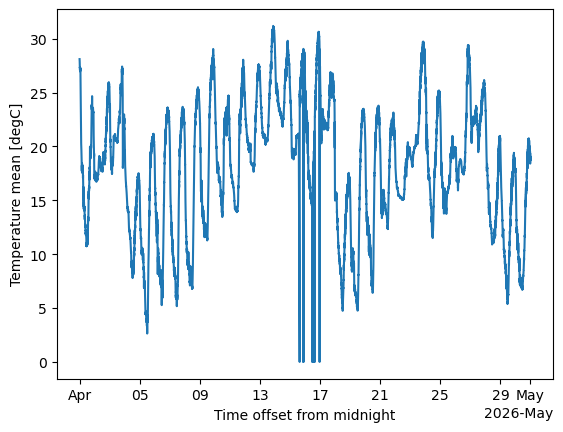

In [112]:
# Since ACT is built upon xarray, we can use xarray's built in plotting to quickly visualize the data
ds_cf_met['temp_mean'].plot()

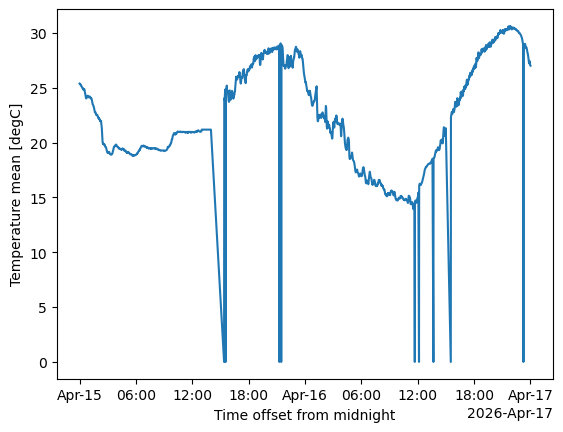

In [113]:
# We can also use xarray's built in slicing to quickly subset the data.  
# Let's look at some suspect data points in the temperature data
ds_cf_met['temp_mean'].sel(time=slice('2026-04-15T00:00', '2026-04-17T00:00')).plot()

## Quality Controlling Data

ARM has multiple methods that it uses to communicate data quality information out to the users.  One of these methods is through **"embedded QC" variables**.  These are variables within the file that have information on automated tests that have been applied.  Many times, they include Min, Max, and Delta tests but as is the case with the [Aerosol Observing System (AOS)](https://armgov.svcs.arm.gov/capabilities/instruments/aos) instruments, there can be more complicated tests that are applied.

The results from all these different tests are stored in a single variable using bit-packed QC.  We won't get into the full details here, but it's a way to communicate the results of multiple tests in a single integer value by utilizing binary and bits!  You can learn more about bit-packed QC [here](https://code.arm.gov/docs/QC-flag-examples/-/wikis/home) but ACT also has many of the tools for working with ARM QC.

### Other Sources of Quality Control
ARM also communicates problems with the data quality through [Data Quality Reports (DQR)](https://dq.arm.gov/#/About).  These reports are normally submitted by the instrument mentor when there's been a problem with the instrument.  The categories include:

- **Data Quality Report Categories**
    - Missing: Data are not available or set to -9999
    - Suspect: The data are not fully incorrect but there are problems that increases the uncertainty of the values. Data should be used with caution.
    - Bad: The data are incorrect and should not be used.
    - Note: Data notes are a way to communicate information that would be useful to the end user but does not rise to the level of suspect or bad data
    
Additionally, data quality information can be found in the Instrument Handbooks, which are included on most instrument pages.  Here is an [example](https://www.arm.gov/publications/tech_reports/handbooks/met_handbook.pdf) of the MET handbook.

In [114]:
# We can see that there's some missing data in the plot above so let's take a look at the embedded QC!
# First, for many of the ACT QC features, we need to get the dataset more to CF standard and that
# involves cleaning up some of the attributes and ways that ARM has historically handled QC
ds_cf_met.clean.cleanup()

# Query the ARM DQR Webservice
variable = 'temp_mean'
ds_cf_met = act.qc.add_dqr_to_qc(ds_cf_met, variable=variable)

In [115]:
ds_cf_met

<xarray.Dataset> Size: 11MB
Dimensions:                       (time: 43076, bound: 2)
Coordinates:
  * time                          (time) datetime64[ns] 345kB 2026-04-01 ... ...
Dimensions without coordinates: bound
Data variables: (12/49)
    base_time                     (time) datetime64[ns] 345kB 2026-04-01 ... ...
    time_offset                   (time) datetime64[ns] 345kB 2026-04-01 ... ...
    time_bounds                   (time, bound) object 689kB dask.array<chunksize=(1440, 2), meta=np.ndarray>
    atmos_pressure                (time) float32 172kB dask.array<chunksize=(1440,), meta=np.ndarray>
    qc_atmos_pressure             (time) int32 172kB dask.array<chunksize=(1440,), meta=np.ndarray>
    temp_mean                     (time) float32 172kB dask.array<chunksize=(1440,), meta=np.ndarray>
    ...                            ...
    qc_logger_volt                (time) int32 172kB dask.array<chunksize=(1440,), meta=np.ndarray>
    logger_temp                   (time) float32 172kB dask.array<chunksize=(1440,), meta=np.ndarray>
    qc_logger_temp                (time) int32 172kB dask.array<chunksize=(1440,), meta=np.ndarray>
    lat                           (time) float32 172kB 36.6 36.6 ... 36.6 36.6
    lon                           (time) float32 172kB -97.49 -97.49 ... -97.49
    alt                           (time) float32 172kB 318.0 318.0 ... 318.0
Attributes: (12/26)
    command_line:                met_ingest -s sgp -f E13 --max-runtime 86400
    Conventions:                 ARM-1.3
    process_version:             ingest-met-4.58-1.el9
    dod_version:                 met-b1-7.7
    input_source:                /data/collection/sgp/sgpmetE13.00/MET_Table1...
    site_id:                     sgp
    ...                          ...
    tbrg_precip_corr_info:       0 * tbrg_precip_total^2 + 0 * tbrg_precip_total
    history:                     created by user armflowprod on machine prod-...
    _file_dates:                 ['20260401', '20260402', '20260403', '202604...
    _file_times:                 ['000000', '000000', '000000', '000000', '00...
    _datastream:                 sgpmetE13.b1
    _arm_standards_flag:         1

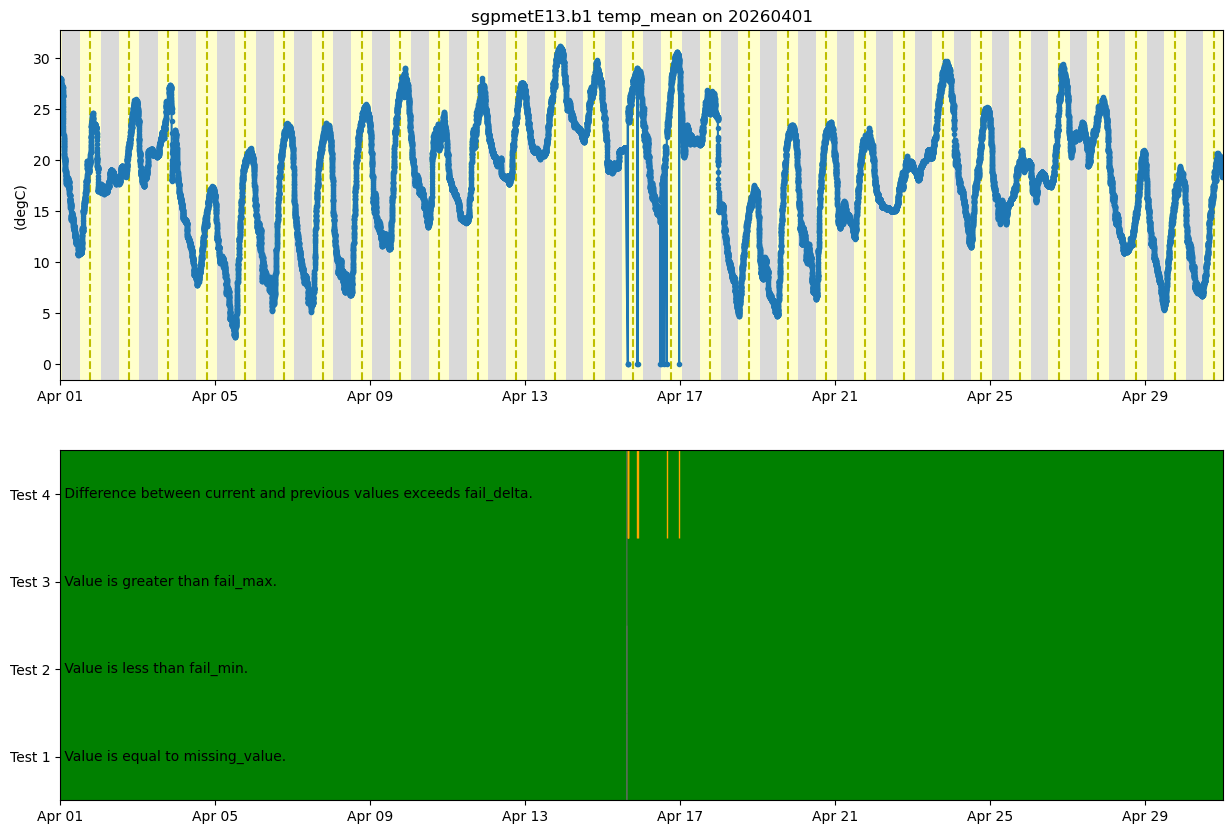

In [116]:
# Next, let's take a look at visualizing the quality control information
# Create a plotting display object with 2 plots
display = act.plotting.TimeSeriesDisplay(ds_cf_met, figsize=(15, 10), subplot_shape=(2,))

# Plot up the variable in the first plot
display.plot(variable, subplot_index=(0,))

# Plot up a day/night background
display.day_night_background(subplot_index=(0,))

# Plot up the QC variable in the second plot
display.qc_flag_block_plot(variable, subplot_index=(1,))
plt.show()

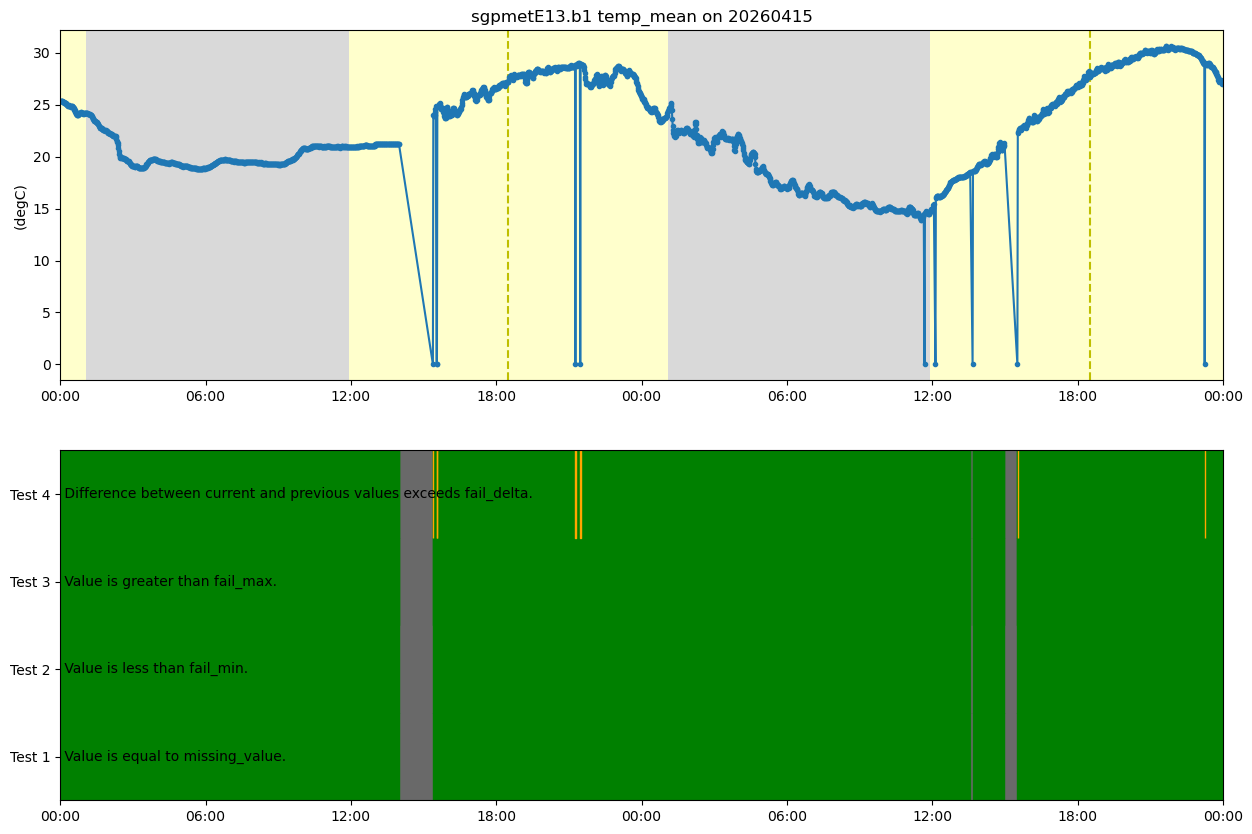

In [117]:
# Next, let's take a look at visualizing the quality control information
# Create a plotting display object with 2 plots
display = act.plotting.TimeSeriesDisplay(ds_cf_met.sel(time=slice('2026-04-15T00:00', '2026-04-17T00:00')), figsize=(15, 10), subplot_shape=(2,))

# Plot up the variable in the first plot
display.plot(variable, subplot_index=(0,))

# Plot up a day/night background
display.day_night_background(subplot_index=(0,))

# Plot up the QC variable in the second plot
display.qc_flag_block_plot(variable, subplot_index=(1,))
plt.show()

## Visualizing Data
We've already worked with visualizing the data in basic ways but what other options are there in ACT?  This section will show you how to create a variety of different plots.  More plotting examples can be found in [ACT's Documentation](https://arm-doe.github.io/ACT/auto_examples/plotting/index.html).

### Multi-Panel Plot
This example shows how to plot multiple datastreams together (both METS) on a multi-panel plot.

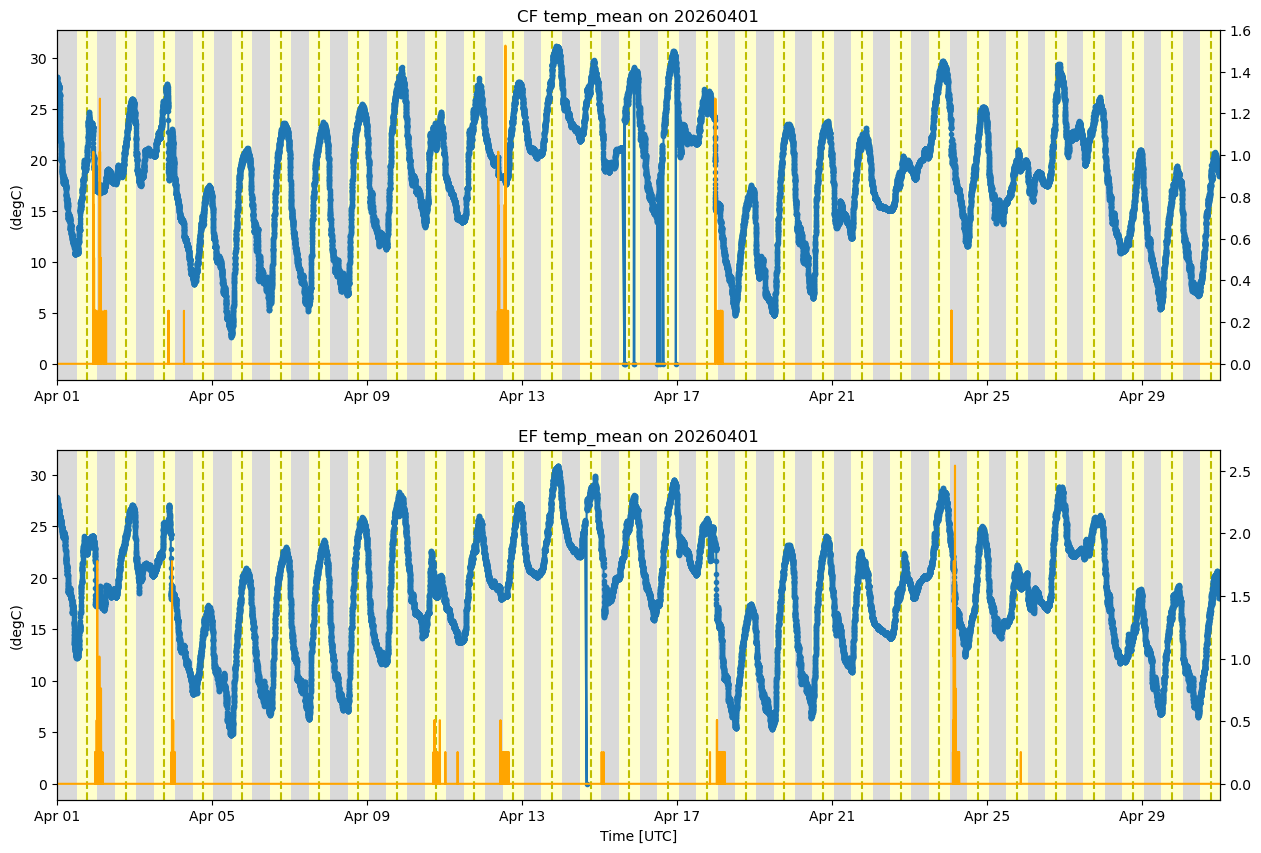

In [118]:
#And plot again!
# Create a plotting display object with 2 plots
# Note we have to create a dictionary of datasets to pass in
display = act.plotting.TimeSeriesDisplay({'CF': ds_cf_met, 'EF': ds_ef_met}, figsize=(15, 10), subplot_shape=(2,))

# Plot up the variable in the first plot
# Need to specify the dsname so it knows which dataset
# to use for this data.  This is helpful when datasets 
# have similar variable names
display.plot('temp_mean', dsname='CF', subplot_index=(0,))
ax1 = display.axes[0].twinx()
ax1.plot(ds_cf_met.time, ds_cf_met.tbrg_precip_total, color='orange')

# Plot up the EF-MET temperature and precipitation
display.plot('temp_mean', dsname='EF', subplot_index=(1,))
ax2 = display.axes[1].twinx()
ax2.plot(ds_ef_met.time, ds_ef_met.tbrg_precip_total, color='orange')

# Plot up a day/night background
display.day_night_background(dsname='CF', subplot_index=(0,))
display.day_night_background(dsname='EF', subplot_index=(1,))

### Adding some customization
Let's make this plot a little nicer and easier to read.  We can use a mix of ACT and Matplotlib to help

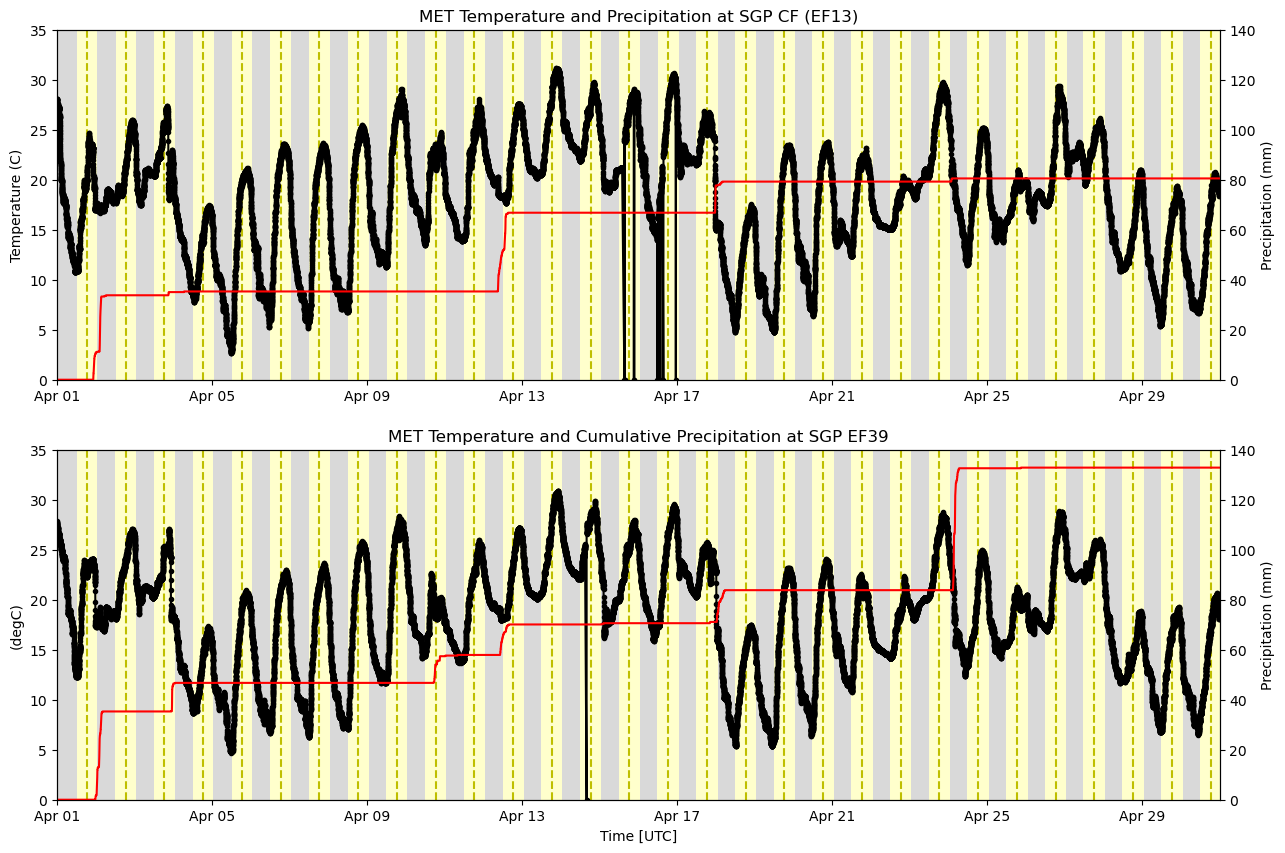

In [119]:
#And plot again!
# Create a plotting display object with 2 plots
# Note we have to create a dictionary of datasets to pass in
display = act.plotting.TimeSeriesDisplay({'CF': ds_cf_met, 'EF': ds_ef_met}, figsize=(15, 10), subplot_shape=(2,))

# Let's accumulate the precipitation using ACT to make this easier to read
ds_cf_met = act.utils.data_utils.accumulate_precip(ds_cf_met, 'tbrg_precip_total')
ds_ef_met = act.utils.data_utils.accumulate_precip(ds_ef_met, 'tbrg_precip_total')

# Let's add in titles and more to the SMPS plot
title = 'MET Temperature and Precipitation at SGP CF (EF13)'
display.plot('temp_mean', dsname='CF', subplot_index=(0,), set_title=title,
             ylabel='Temperature (C)', color='black')
display.set_yrng([0, 35], subplot_index=(0,))
ax1 = display.axes[0].twinx()
ax1.plot(ds_cf_met.time, ds_cf_met.tbrg_precip_total_accumulated, color='red')
ax1.set_ylabel('Precipitation (mm)')
ax1.set_ylim([0, 140.0])

# Plot up the MET btemperature and precipitation
title = 'MET Temperature and Cumulative Precipitation at SGP EF39'
display.plot('temp_mean', dsname='EF', subplot_index=(1,), set_title=title, color='black')
display.set_yrng([0, 35], subplot_index=(1,))
ax2 = display.axes[1].twinx()
ax2.plot(ds_ef_met.time, ds_ef_met.tbrg_precip_total_accumulated, color='red')
ax2.set_ylabel('Precipitation (mm)')
ax2.set_ylim([0, 140.0])

# Plot up a day/night background
display.day_night_background(dsname='CF', subplot_index=(0,))
display.day_night_background(dsname='EF', subplot_index=(1,))

### Distribution Display

For the example, we will go over some functions within ACT's distribution display. Functions such as, the stacked bar plot, scatter and groupby.

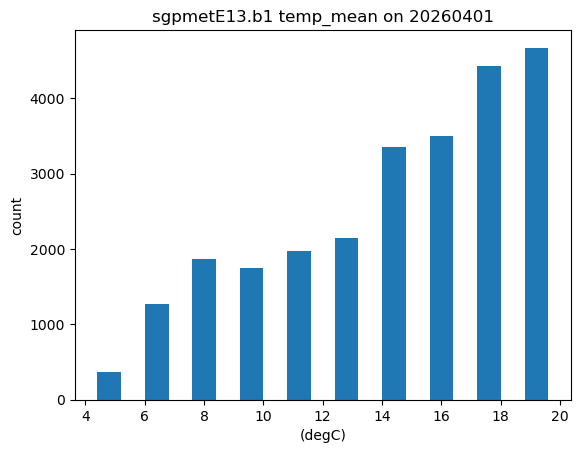

In [120]:
# First, let's plot up a histogram of the data
# All the ACT plotting is very similar to what we
# did earlier, first we create a display object
display = act.plotting.DistributionDisplay(ds_cf_met)

# And then we can plot the data!  Note that we are passing a range into the
# histogram function to set the min/max range of the data
display.plot_stacked_bar('temp_mean', hist_kwargs={'range': [4, 20]})
plt.show()

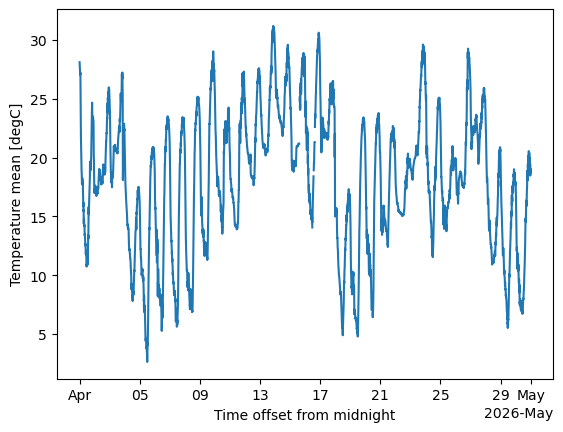

In [121]:
# Let's directly compare the two datasets using a scatter plot. 
# First we need to clean up the datasets and average to the same time grid
# Once again, we take advantage of the xarray data structures and use xarray's resample function
ds_cf_qc = ds_cf_met.where(ds_cf_met.temp_mean > 0).resample(time='10min').nearest()
ds_ef_qc = ds_ef_met.where(ds_ef_met.temp_mean > 0).resample(time='10min').nearest()

# Note - plenty of ways to do this, but adding a suffix to distinguish between two sites
suffix = "_ef"
exclude = ["base_time", "time_bounds", "time_offset", "lat", "lon", "alt"]
ds_ef_qc = ds_ef_qc.rename_vars({
    var: f"{var}{suffix}"
    for var in ds_ef_qc.data_vars
    if var not in exclude
})

# quick check to make sure we've eliminated the questionable data
ds_cf_qc.temp_mean.plot(label='CF-MET')

:::{admonition}**More Information on Combining Data with Xarray**
Find more information on combining data with xarray [here](https://docs.xarray.dev/en/stable/user-guide/combining.html)
:::

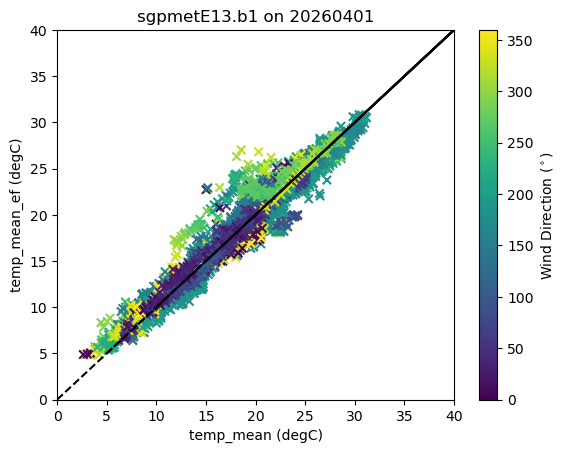

In [122]:
# Combine the datasets together using xarray's merge function.
ds_combined = xr.merge([ds_cf_qc, ds_ef_qc], compat='override')

# Next up, let's do some scatter plots to compare some variables
# Scatter plots are also found in the DistributionDisplay module
display = act.plotting.DistributionDisplay(ds_combined)
display.set_xrng([0, 40])
display.set_yrng([0, 40])

# And then we can plot the data!
display.plot_scatter('temp_mean', 
                     'temp_mean_ef', 
                     m_field='wdir_vec_mean',
                     marker='x',
                     cbar_label=r'Wind Direction ($^\circ$)',
)

# Display the 1:1 ratio line
display.set_ratio_line()

plt.show()

### Data Rose Plots

If your data may be wind speed or direction dependent, these plots can help inform where the influences may be coming from (or confirm there are no blocking QC issues).  For this example, let's see if tipping bucket rain guage data are dependent on wind direction

/Users/jrobrien/.vscode-micromamba/envs/arm-summer-school-2026-dev/lib/python3.11/site-packages/act/plotting/windrosedisplay.py:358: RuntimeWarning: Mean of empty slice
  arr.append(np.nanmean(data[idx]))


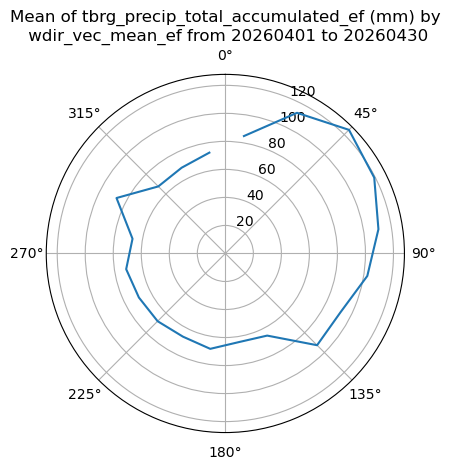

In [123]:
# Plot out the data rose using the WindRose display object
display = act.plotting.WindRoseDisplay(ds_combined)
display.plot_data('wdir_vec_mean_ef', 'wspd_vec_mean_ef', 'tbrg_precip_total_accumulated_ef', num_dirs=20, plot_type='line', line_plot_calc='mean')
plt.show()

/Users/jrobrien/.vscode-micromamba/envs/arm-summer-school-2026-dev/lib/python3.11/site-packages/act/plotting/windrosedisplay.py:429: RuntimeWarning: Mean of empty slice
  mean_data[i, j] = np.nanmean(data[idx])


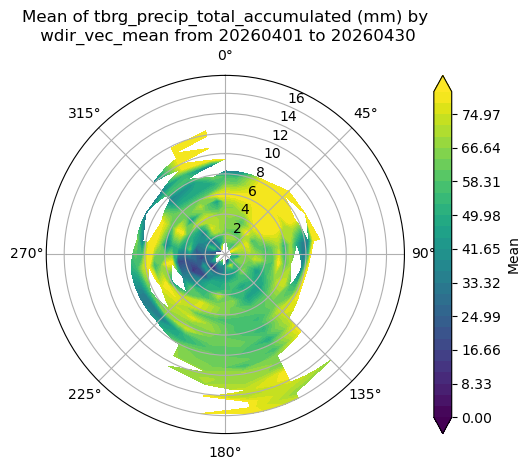

In [124]:
# Plot out the data rose using the WindRose display object
display = act.plotting.WindRoseDisplay(ds_combined)

# Let's try a different type of data rose type that is using contours amd the polar y axis is wind speed
# depending on wind direction and speed
display.plot_data('wdir_vec_mean', 'wspd_vec_mean', 'tbrg_precip_total_accumulated', num_dirs=20, plot_type='contour', contour_type='mean')
plt.show()

---